Feature Engineering:

1)_Filtrado de Outliers

 → 2. Estandarización de Datos 

 → 3. Transformación Logarítmica (si es necesario) 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pathlib
import sys
import scipy.stats as stats

In [2]:
df_dbt = pd.read_csv(
    r"D:\4_IA y ML en Cs Biol\Especializacion_ML_\Proyectos\1_DBT_Prediction\data\raw\diabetes.csv"
)

In [3]:
df_dbt.shape

(768, 9)

In [4]:
df_dbt.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# remember lower bound and upper bound to compare with the reference values of some variables in the dataset
for i, column in enumerate(df_dbt.columns, 1):
    Q1 = df_dbt[column].quantile(0.25)
    Q3 = df_dbt[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(
        f"{column}: lower_bound= {round(lower_bound,2)},upper_bound= {round(upper_bound, 2)}"
    )

Pregnancies: lower_bound= -6.5,upper_bound= 13.5
Glucose: lower_bound= 37.12,upper_bound= 202.12
BloodPressure: lower_bound= 35.0,upper_bound= 107.0
SkinThickness: lower_bound= -48.0,upper_bound= 80.0
Insulin: lower_bound= -190.88,upper_bound= 318.12
BMI: lower_bound= 13.35,upper_bound= 50.55
DiabetesPedigreeFunction: lower_bound= -0.33,upper_bound= 1.2
Age: lower_bound= -1.5,upper_bound= 66.5
Outcome: lower_bound= -1.5,upper_bound= 2.5


Remove Outliers

In [6]:
import sys

script_preprocesing_path = r"D:\4_IA y ML en Cs Biol\Especializacion_ML_\Proyectos\1_DBT_Prediction\src\Feature_engineering"
sys.path.append(script_preprocesing_path)
import preprocessing as pp

In [7]:
df_dbt_filtered = pp.outlier_remove(df_dbt)

In [8]:
print(f"Shape of the dataset before removing outliers: {df_dbt.shape}")
print(f"Shape of the dataset after removing outliers: {df_dbt_filtered.shape}")

Shape of the dataset before removing outliers: (768, 9)
Shape of the dataset after removing outliers: (332, 9)


In [9]:
df_dbt_filtered.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
6,3,78,50,32,88,31.0,0.248,26,1
14,5,166,72,19,175,25.8,0.587,51,1
16,0,118,84,47,230,45.8,0.551,31,1
19,1,115,70,30,96,34.6,0.529,32,1


Distribution of dataset without Outliers

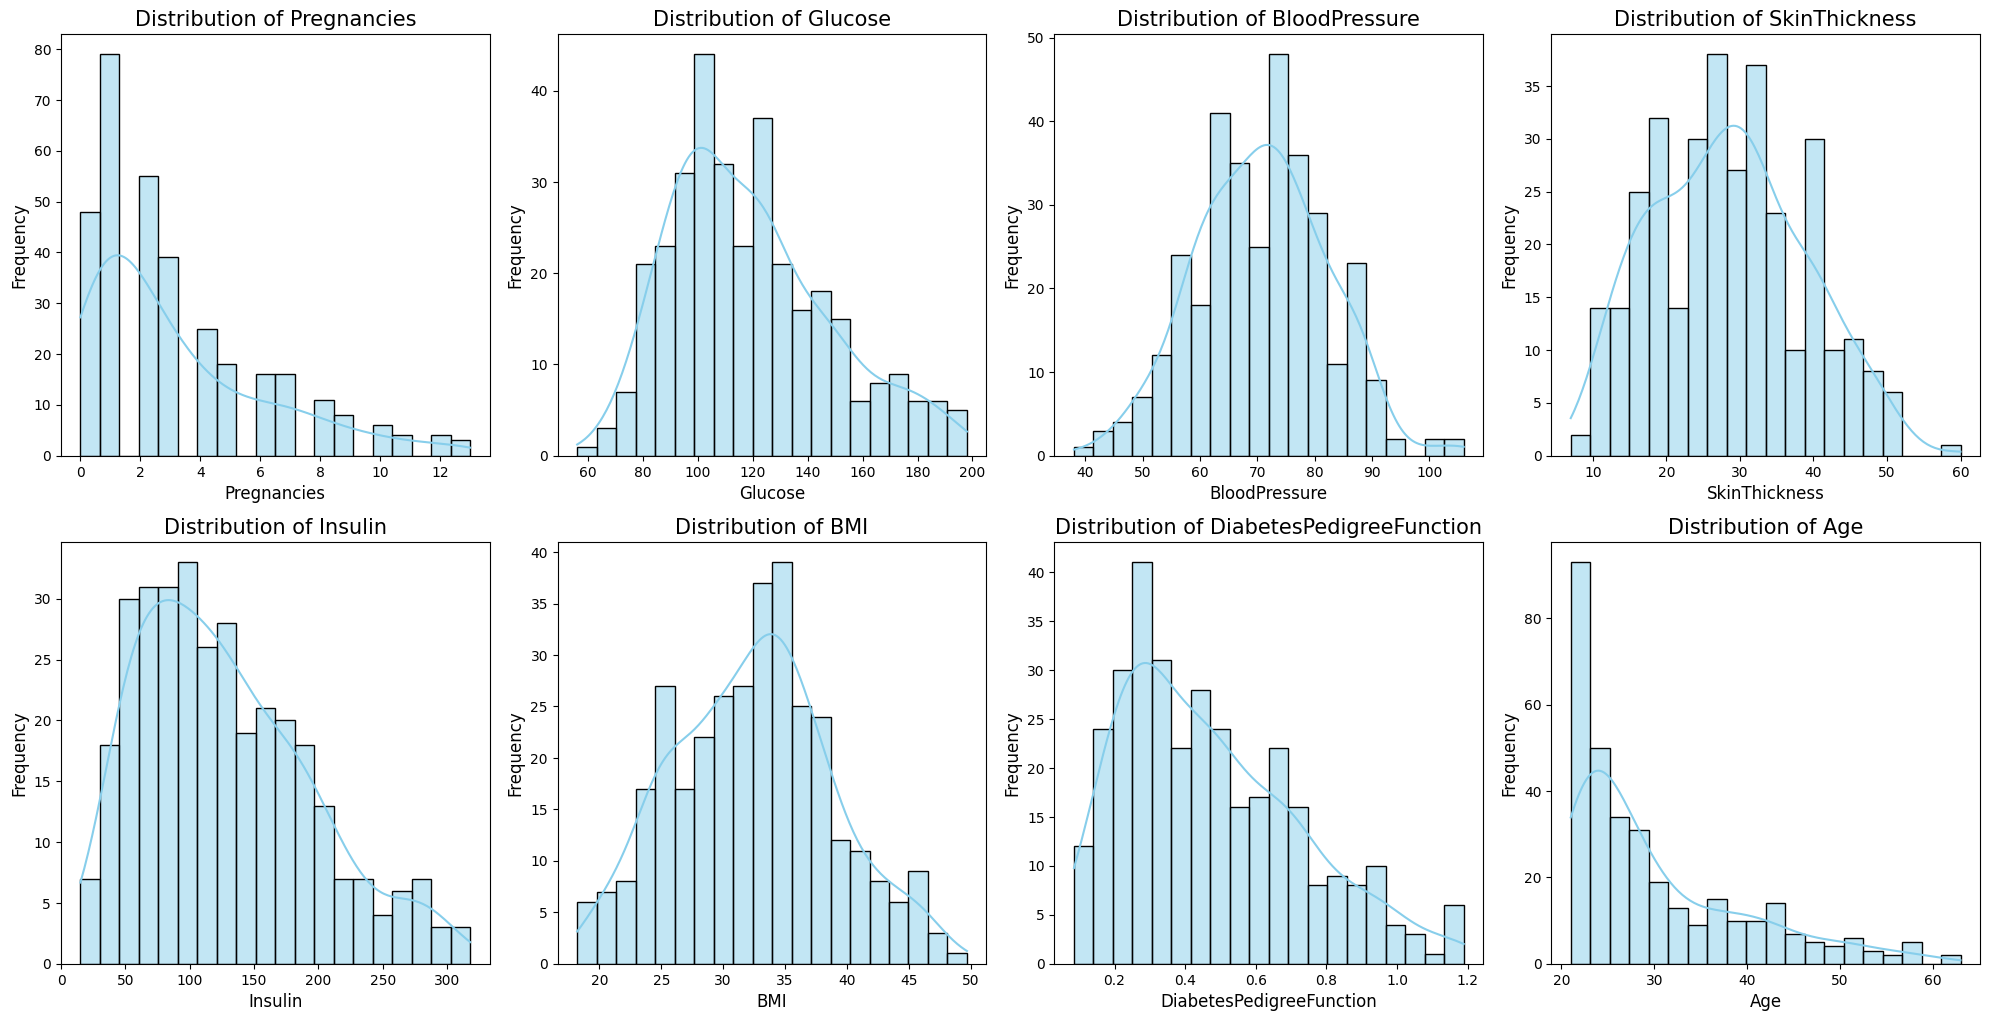

In [10]:
scrip_distribution_path = (
    r"D:\4_IA y ML en Cs Biol\Especializacion_ML_\Proyectos\1_DBT_Prediction\src\EDA"
)
sys.path.append(scrip_distribution_path)

import distribution as dist

dist.plot_distribution(df_dbt_filtered.drop(columns="Outcome"))

In [11]:
dist.compute_skewness(df_dbt_filtered.drop(columns="Outcome"))

Pregnancies                 1.220372
Glucose                     0.650748
BloodPressure               0.080620
SkinThickness               0.222204
Insulin                     0.683730
BMI                         0.140795
DiabetesPedigreeFunction    0.728722
Age                         1.275003
dtype: float64

In [27]:
# saved data_filtered
file_path = r"D:\4_IA y ML en Cs Biol\Especializacion_ML_\Proyectos\1_DBT_Prediction\data\processed_data\diabetes_filtered.csv"
df_dbt_filtered.to_csv(file_path, index=False)
print(f"Data has been saved in {file_path}")

Data has been saved in D:\4_IA y ML en Cs Biol\Especializacion_ML_\Proyectos\1_DBT_Prediction\data\processed_data\diabetes_filtered.csv


Standarization

"Standardizing the data is crucial for logistic regression, as it ensures that all features are on the same scale, preventing variables with larger ranges from dominating the model. This improves training efficiency, optimizes performance in models with regularization, and facilitates the interpretation of coefficients. Additionally, standardization helps the model’s numerical stability and allows for faster and more accurate convergence during the optimization process, ensuring more balanced learning across the variables."

In [12]:
df_dbt_standardized = pp.standardize_features(df_dbt_filtered)

In [13]:
df_dbt_standardized.shape

(332, 9)

In [14]:
df_dbt_standardized.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,-0.721270,-1.025143,-0.414771,-0.526646,-0.494252,-0.679103,-1.212975,-0.981035,0
1,-0.058859,-1.402240,-1.819912,0.347101,-0.584396,-0.223941,-0.892156,-0.449361,1
2,0.603552,1.614538,0.112157,-0.914977,0.722688,-1.040094,0.450534,2.209011,1
3,-1.052476,-0.030977,1.166014,1.803344,1.549006,2.098955,0.307947,0.082313,1
4,-0.721270,-0.133822,-0.063485,0.152935,-0.464204,0.341088,0.220811,0.188648,1


In [ ]:
print(
    f'Mean of the standardized dataset:\n{df_dbt_standardized.drop(columns=["Outcome"]).mean()}'
)
print(
    f'\nStandard deviation of the standardized dataset:\n{df_dbt_standardized.drop(columns=["Outcome"]).std()}'
)

Mean of the standardized dataset:
Pregnancies                -3.210283e-17
Glucose                     4.012854e-17
BloodPressure              -1.605142e-16
SkinThickness              -1.284113e-16
Insulin                     5.617996e-17
BMI                        -1.417875e-16
DiabetesPedigreeFunction    4.173368e-16
Age                         3.477807e-17
dtype: float64

Standard deviation of the standardized dataset:
Pregnancies                 1.001509
Glucose                     1.001509
BloodPressure               1.001509
SkinThickness               1.001509
Insulin                     1.001509
BMI                         1.001509
DiabetesPedigreeFunction    1.001509
Age                         1.001509
dtype: float64


Distribution of standardized data

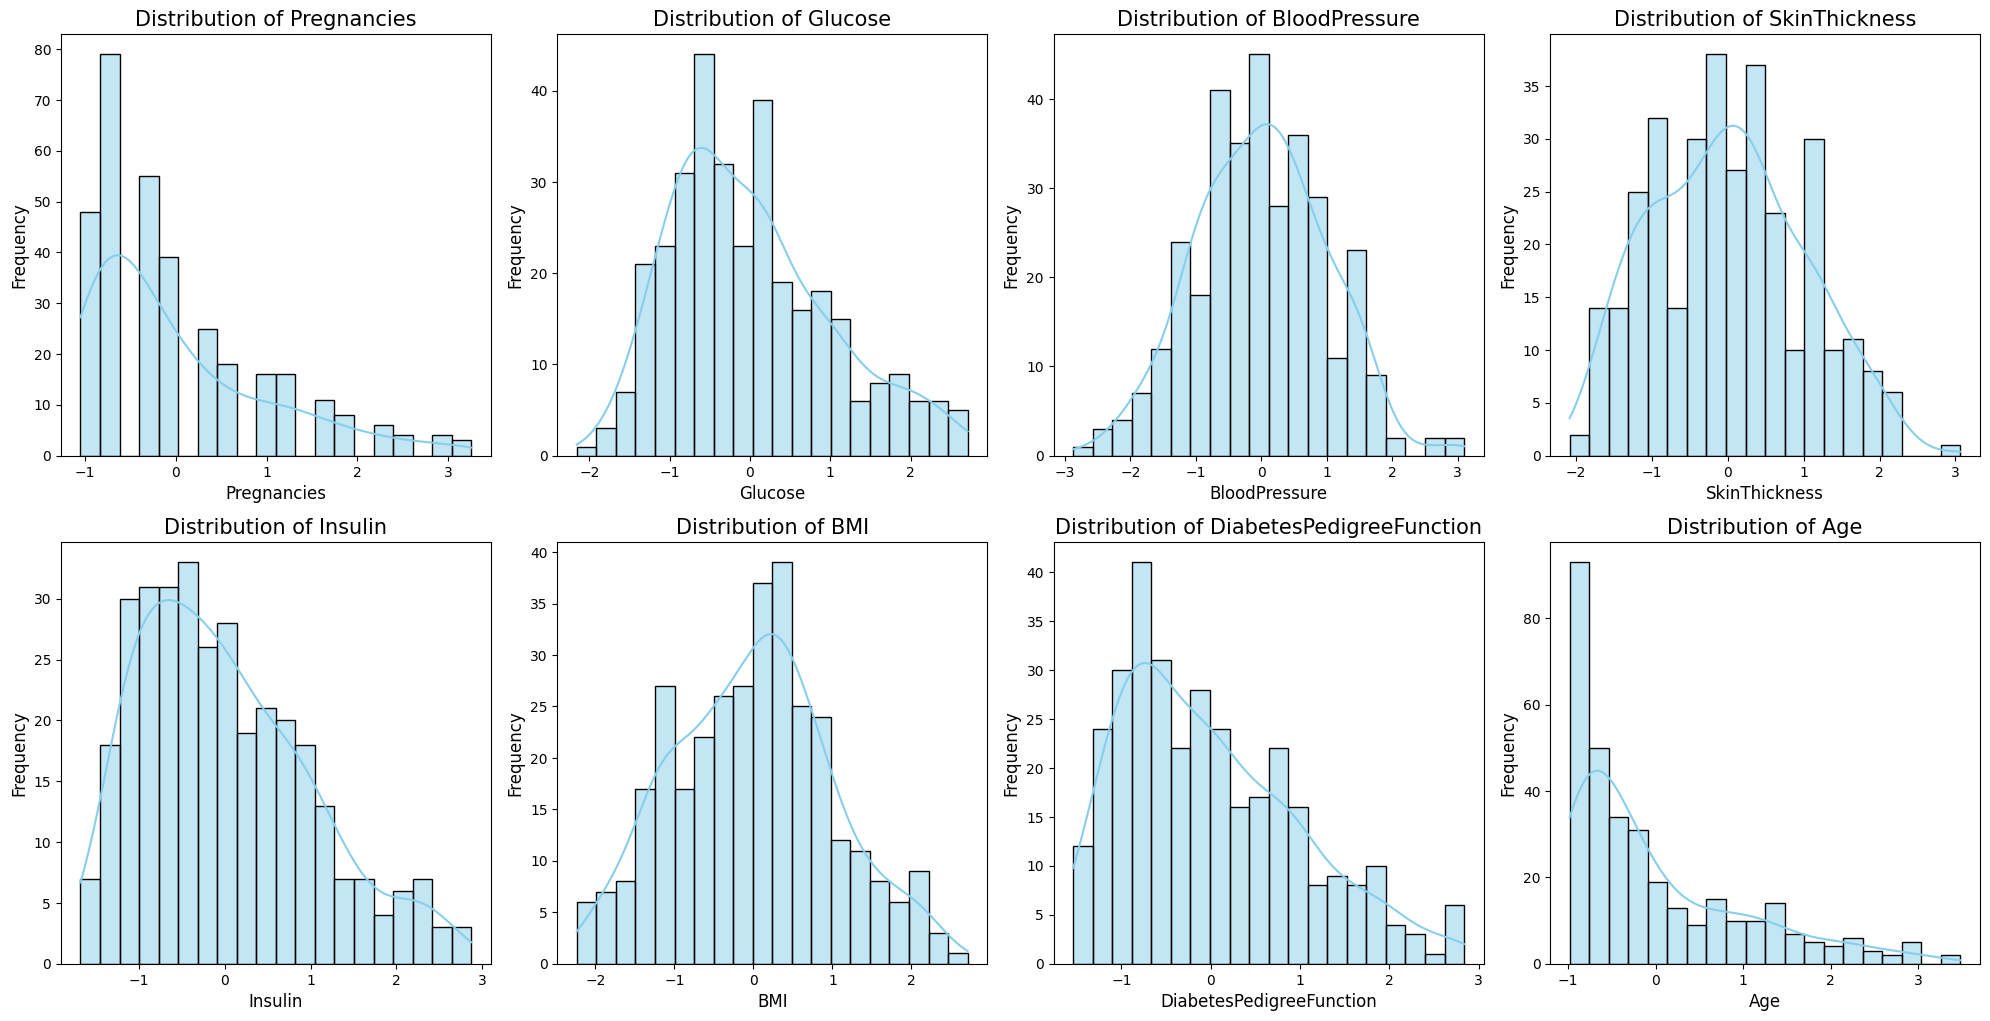

In [16]:
dist.plot_distribution(df_dbt_standardized.drop(columns="Outcome"))

In [17]:
# asymmetry of the standardized data
dist.compute_skewness(df_dbt_standardized.drop(columns="Outcome"))

Pregnancies                 1.220372
Glucose                     0.650748
BloodPressure               0.080620
SkinThickness               0.222204
Insulin                     0.683730
BMI                         0.140795
DiabetesPedigreeFunction    0.728722
Age                         1.275003
dtype: float64

In [18]:
# Define the file path for saving the standardized dataset
file_path = r"D:\4_IA y ML en Cs Biol\Especializacion_ML_\Proyectos\1_DBT_Prediction\data\processed_data\diabetes_standardized.csv"


# Save the standardized dataset to CSV
df_dbt_standardized.to_csv(file_path, index=False)

print(f"Dataset successfully saved to {file_path}")

Dataset successfully saved to D:\4_IA y ML en Cs Biol\Especializacion_ML_\Proyectos\1_DBT_Prediction\data\processed_data\diabetes_standardized.csv


Nomalization

"Normalizing the data is crucial for models that rely on distance metrics, such as KNN or neural networks, as it ensures that all features are on the same scale, typically within a range of 0 to 1. This prevents variables with larger ranges from dominating the model. Normalization improves training efficiency, optimizes performance, and helps models converge more quickly by stabilizing the learning process. Additionally, it facilitates the interpretation of model behavior and ensures more balanced learning across the features, leading to better overall performance in models sensitive to the scale of the data."

In [20]:
df_dbt_normalized = pp.normalize_feature(df_dbt_filtered)

In [21]:
df_dbt_normalized.shape

(332, 9)

In [22]:
df_dbt_normalized.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.076923,0.232394,0.411765,0.301887,0.260726,0.314286,0.074275,0.000000,0
1,0.230769,0.154930,0.176471,0.471698,0.240924,0.406349,0.147645,0.119048,1
2,0.384615,0.774648,0.500000,0.226415,0.528053,0.241270,0.454710,0.714286,1
3,0.000000,0.436620,0.676471,0.754717,0.709571,0.876190,0.422101,0.238095,1
4,0.076923,0.415493,0.470588,0.433962,0.267327,0.520635,0.402174,0.261905,1


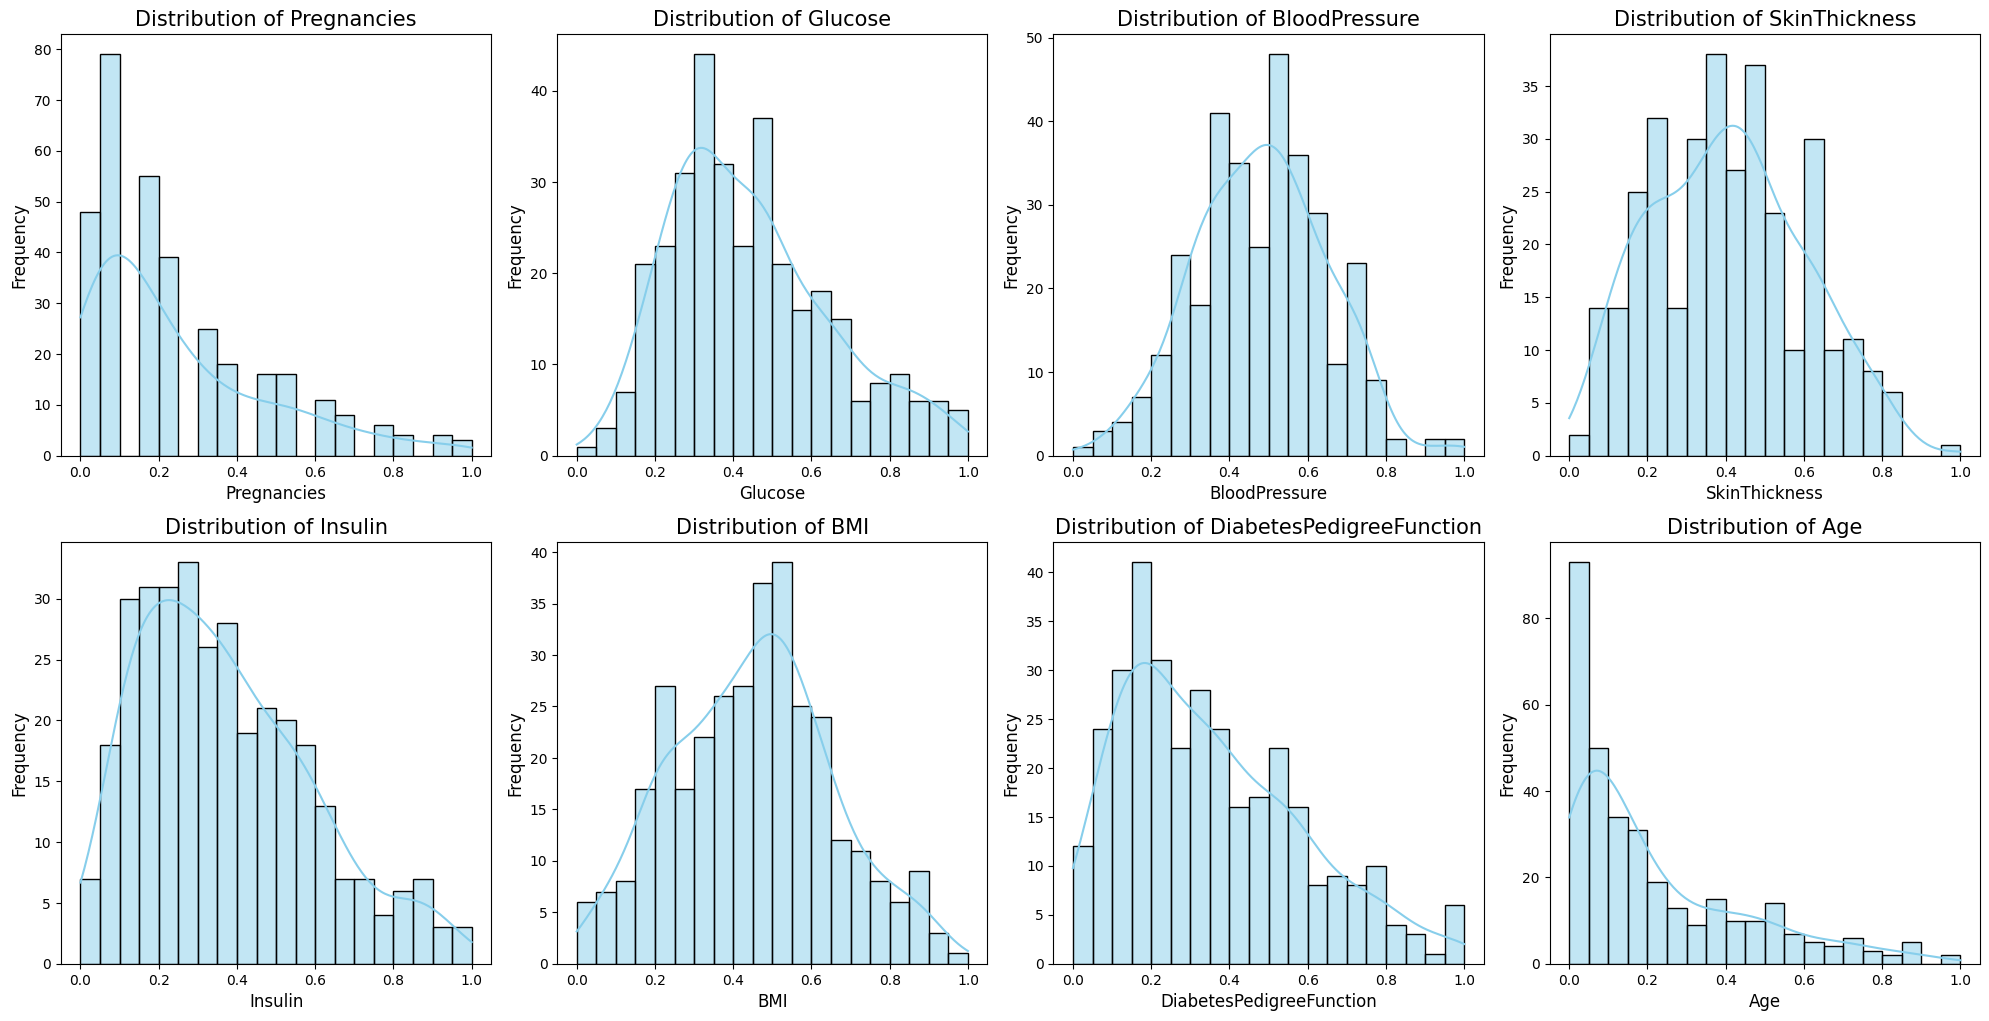

In [23]:
dist.plot_distribution(df_dbt_normalized.drop(columns="Outcome"))

In [24]:
dist.compute_skewness(df_dbt_normalized.drop(columns="Outcome"))

Pregnancies                 1.220372
Glucose                     0.650748
BloodPressure               0.080620
SkinThickness               0.222204
Insulin                     0.683730
BMI                         0.140795
DiabetesPedigreeFunction    0.728722
Age                         1.275003
dtype: float64

In [25]:
# Save the normalized dataset to CSV
file_path = r"D:\4_IA y ML en Cs Biol\Especializacion_ML_\Proyectos\1_DBT_Prediction\data\processed_data\diabetes_normalized.csv"

df_dbt_normalized.to_csv(file_path, index=False)
print(f"Dataset successfully saved to {file_path}")

Dataset successfully saved to D:\4_IA y ML en Cs Biol\Especializacion_ML_\Proyectos\1_DBT_Prediction\data\processed_data\diabetes_normalized.csv


Transformation
Age and Pregnancies present asymmetry after standardization and normalization, so:
What transformations can I use?
📌 Logarithm (log): Useful for highly positively skewed values.
📌 Square root (sqrt): Reduces moderate skewness without significantly altering the scale.
📌 Box-Cox or Yeo-Johnson: More general methods that automatically adjust the transformation.


Clarification:


We are using models that can tolerate asymmetry in the data, and only two out of the nine features (Age and Pregnancies) show significant skewness. For now, we are not applying any transformations to these features. We will proceed with data that is outlier-free, standardized, and normalized.


However, if the model performance does not improve or if we notice that the skewness of certain features (like Age or Pregnancies) negatively impacts the results, we may consider applying transformations (such as log or square root) to those specific features in the future.


